In [1]:
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'High-Income': '#2196F3', 'Low-Income': '#F44336'}
np.random.seed(42)

print(" All libraries loaded successfully.")

 All libraries loaded successfully.


In [2]:
from google.colab import files

uploaded = files.upload()  # select your listings.csv here

raw_df = pd.read_csv('listings.csv', low_memory=False)

print(f" File loaded!")
print(f"Shape: {raw_df.shape}")
print(f"Total columns: {len(raw_df.columns)}")
print(f"\nAll columns:\n{list(raw_df.columns)}")


Saving listings.csv to listings.csv
 File loaded!
Shape: (14274, 18)
Total columns: 18

All columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [3]:
# CELL 3 — Check all columns and first few rows
print("All columns:")
print(list(raw_df.columns))

print(f"\nFirst 3 rows:")
print(raw_df.head(3))

print(f"\nData types:")
print(raw_df.dtypes)

print(f"\nMissing values:")
print(raw_df.isnull().sum())

All columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']

First 3 rows:
      id                                 name  host_id       host_name  \
0   3176      Fabulous Flat in great Location     3718          Britta   
1   9991  Geourgeous flat - outstanding views    33852         Philipp   
2  14325  Studio Apartment in Prenzlauer Berg    55531  Chris + Oliver   

  neighbourhood_group             neighbourhood  latitude  longitude  \
0              Pankow   Prenzlauer Berg Südwest  52.53471   13.41810   
1              Pankow   Prenzlauer Berg Südwest  52.53269   13.41805   
2              Pankow  Prenzlauer Berg Nordwest  52.54813   13.40366   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0  Entire home/apt 

In [4]:
# CELL 4 — Data Cleaning
df = raw_df.copy()

# Drop columns not useful for ML
df.drop(columns=['name', 'host_name', 'last_review', 'license'], inplace=True)

# Drop rows where price is missing
df.dropna(subset=['price'], inplace=True)

# Remove price outliers (keep €5 to €1500)
df = df[(df['price'] >= 5) & (df['price'] <= 1500)]

# Fill missing reviews_per_month with 0
df['reviews_per_month'].fillna(0, inplace=True)

# Drop remaining nulls
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

print(f" Cleaned dataset shape: {df.shape}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nPrice range: €{df['price'].min():.0f} – €{df['price'].max():.0f}")
print(f"Median price: €{df['price'].median():.0f}")


 Cleaned dataset shape: (9234, 14)

Missing values after cleaning:
id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
dtype: int64

Price range: €5 – €1500
Median price: €104


In [5]:
# CELL 5 — Assign Sensitive Attribute (Neighbourhood Income Group)
# Based on Berlin Senate income statistics (Amt für Statistik, 2022)

HIGH_INCOME = [
    'Mitte', 'Prenzlauer Berg', 'Charlottenburg', 'Wilmersdorf',
    'Steglitz', 'Zehlendorf', 'Friedrichshain', 'Pankow'
]

LOW_INCOME = [
    'Neukölln', 'Marzahn', 'Spandau', 'Reinickendorf',
    'Lichtenberg', 'Tempelhof', 'Wedding', 'Hellersdorf',
    'Köpenick', 'Treptow'
]

def assign_income_group(neighbourhood):
    if any(h.lower() in str(neighbourhood).lower() for h in HIGH_INCOME):
        return 'High-Income'
    elif any(l.lower() in str(neighbourhood).lower() for l in LOW_INCOME):
        return 'Low-Income'
    else:
        return 'Other'

df['income_group'] = df['neighbourhood'].apply(assign_income_group)

# Also try neighbourhood_group column as backup
print("Income group distribution (from neighbourhood column):")
print(df['income_group'].value_counts())

print(f"\nUnique neighbourhood_group values:")
print(df['neighbourhood_group'].unique())

print(f"\nSample neighbourhoods per income group:")
for grp in ['High-Income', 'Low-Income', 'Other']:
    sample = df[df['income_group'] == grp]['neighbourhood'].unique()[:5]
    print(f"  {grp}: {list(sample)}")

Income group distribution (from neighbourhood column):
income_group
Other          6925
High-Income    1422
Low-Income      887
Name: count, dtype: int64

Unique neighbourhood_group values:
['Pankow' 'Neukölln' 'Mitte' 'Friedrichshain-Kreuzberg'
 'Charlottenburg-Wilm.' 'Tempelhof - Schöneberg' 'Lichtenberg'
 'Steglitz - Zehlendorf' 'Treptow - Köpenick' 'Reinickendorf'
 'Marzahn - Hellersdorf' 'Spandau']

Sample neighbourhoods per income group:
  High-Income: ['Prenzlauer Berg Südwest', 'Prenzlauer Berg Nordwest', 'Prenzlauer Berg Süd', 'Prenzlauer Berg Nord', 'Pankow Zentrum']
  Low-Income: ['Tempelhofer Vorstadt', 'Wedding Zentrum', 'Tempelhof', 'Alt  Treptow', 'Köpenick-Nord']
  Other: ['Reuterstraße', 'Brunnenstr. Süd', 'Helmholtzplatz', 'Düsseldorfer Straße', 'Schöneberg-Nord']


In [6]:
# CELL 6 — Use neighbourhood_group to assign income groups
# (since this dataset uses broader district names)

print("All unique neighbourhood_group values:")
print(df['neighbourhood_group'].value_counts())
print("\nAll unique neighbourhood values (sample):")
print(df['neighbourhood'].unique()[:30])

All unique neighbourhood_group values:
neighbourhood_group
Mitte                       2079
Friedrichshain-Kreuzberg    1909
Pankow                      1402
Charlottenburg-Wilm.        1128
Neukölln                     730
Tempelhof - Schöneberg       636
Treptow - Köpenick           445
Steglitz - Zehlendorf        286
Lichtenberg                  250
Reinickendorf                155
Spandau                      115
Marzahn - Hellersdorf         99
Name: count, dtype: int64

All unique neighbourhood values (sample):
['Prenzlauer Berg Südwest' 'Prenzlauer Berg Nordwest' 'Reuterstraße'
 'Brunnenstr. Süd' 'Tempelhofer Vorstadt' 'Helmholtzplatz'
 'Düsseldorfer Straße' 'Schöneberg-Nord' 'südliche Luisenstadt'
 'Frankfurter Allee Süd FK' 'Neue Kantstraße' 'Prenzlauer Berg Süd'
 'Brunnenstr. Nord' 'Prenzlauer Berg Nord' 'Schmargendorf'
 'Alexanderplatz' 'Blankenfelde/Niederschönhausen' 'Schöneberg-Süd'
 'Südliche Friedrichstadt' 'Wiesbadener Straße'
 'Blankenburg/Heinersdorf/Märchenland' 'P

In [7]:
# CELL 7 — Correct Income Group Mapping using neighbourhood_group
# Based on Berlin Senate income statistics (Amt für Statistik, 2022)

HIGH_INCOME_GROUPS = [
    'Mitte',
    'Friedrichshain-Kreuzberg',
    'Pankow',
    'Charlottenburg-Wilm.',
    'Steglitz - Zehlendorf'
]

LOW_INCOME_GROUPS = [
    'Neukölln',
    'Tempelhof - Schöneberg',
    'Treptow - Köpenick',
    'Lichtenberg',
    'Reinickendorf',
    'Spandau',
    'Marzahn - Hellersdorf'
]

def assign_income_group(district):
    if district in HIGH_INCOME_GROUPS:
        return 'High-Income'
    elif district in LOW_INCOME_GROUPS:
        return 'Low-Income'
    else:
        return 'Other'

df['income_group'] = df['neighbourhood_group'].apply(assign_income_group)

print(" Income group distribution:")
print(df['income_group'].value_counts())

print(f"\nHigh-price rate by income group (raw):")
MEDIAN_PRICE = df['price'].median()
df['price_label'] = (df['price'] > MEDIAN_PRICE).astype(int)
print(df.groupby('income_group')['price_label'].mean().round(4))

print(f"\nMedian price by income group:")
print(df.groupby('income_group')['price'].median())

 Income group distribution:
income_group
High-Income    6804
Low-Income     2430
Name: count, dtype: int64

High-price rate by income group (raw):
income_group
High-Income    0.5310
Low-Income     0.4012
Name: price_label, dtype: float64

Median price by income group:
income_group
High-Income    110.0
Low-Income      90.0
Name: price, dtype: float64


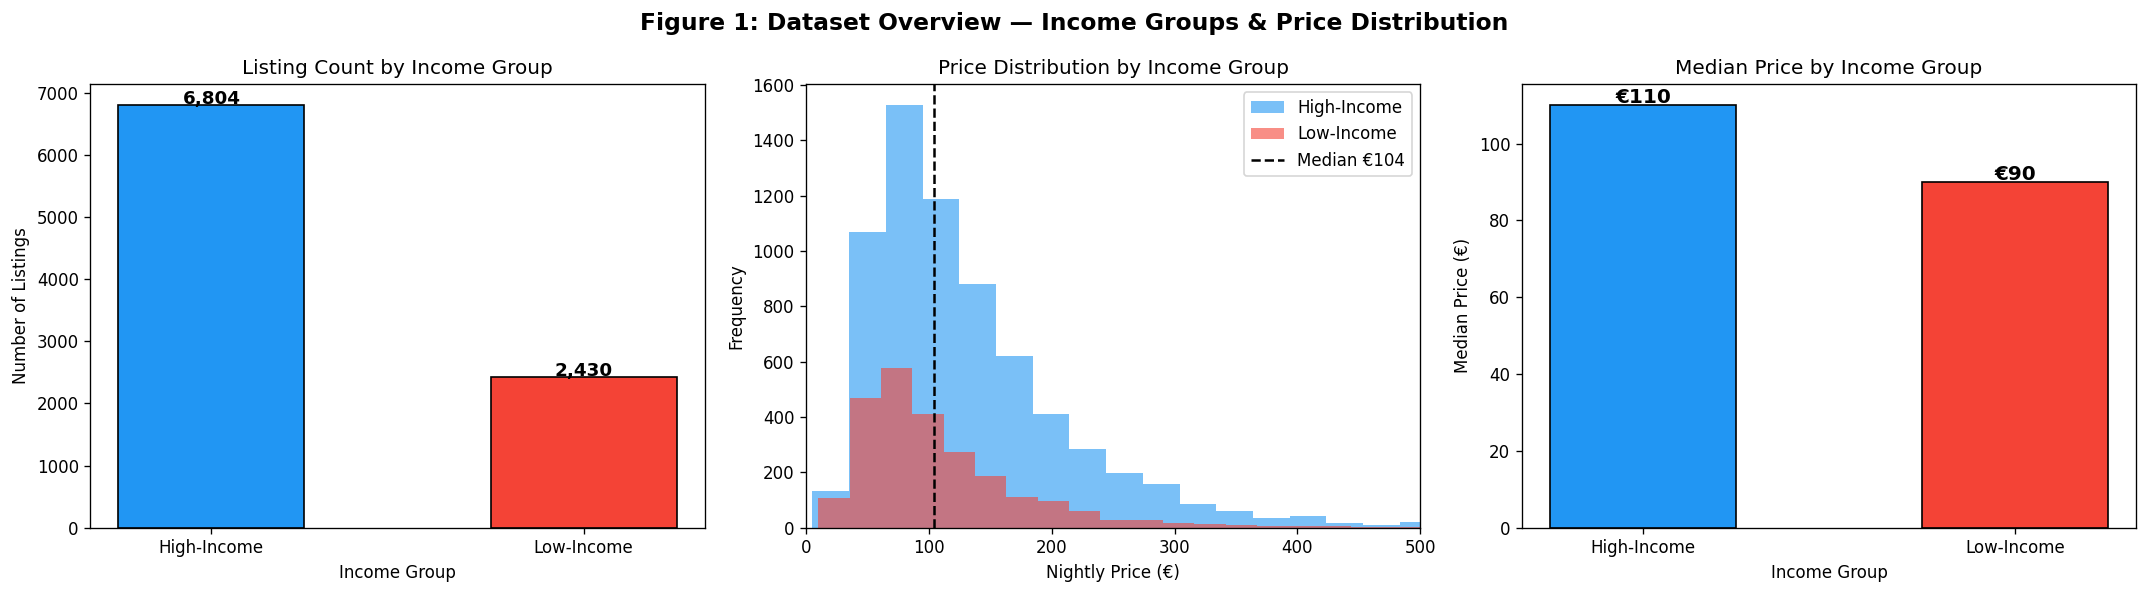

In [8]:
# CELL 8 — Exploratory Data Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 1: Dataset Overview — Income Groups & Price Distribution',
             fontsize=14, fontweight='bold')

# Filter to only High and Low income for plots
df_hl = df[df['income_group'].isin(['High-Income', 'Low-Income'])].copy()

# Plot 1: Listing count
counts = df_hl['income_group'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE['High-Income'], PALETTE['Low-Income']],
                   edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Listing Count by Income Group')
axes[0].set_ylabel('Number of Listings')
axes[0].set_xlabel('Income Group')

# Plot 2: Price histogram
for group, color in PALETTE.items():
    subset = df_hl[df_hl['income_group'] == group]['price']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color,
                 label=group, edgecolor='none')
axes[1].axvline(df_hl['price'].median(), color='black',
                linestyle='--', linewidth=1.5,
                label=f'Median €{df_hl["price"].median():.0f}')
axes[1].set_title('Price Distribution by Income Group')
axes[1].set_xlabel('Nightly Price (€)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 500)

# Plot 3: Median price by income group
medians = df_hl.groupby('income_group')['price'].median()
bars2 = axes[2].bar(medians.index, medians.values,
                    color=[PALETTE['High-Income'], PALETTE['Low-Income']],
                    edgecolor='black', width=0.5)
for bar, val in zip(bars2, medians.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'€{val:.0f}', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Median Price by Income Group')
axes[2].set_ylabel('Median Price (€)')
axes[2].set_xlabel('Income Group')

plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight')
plt.show()

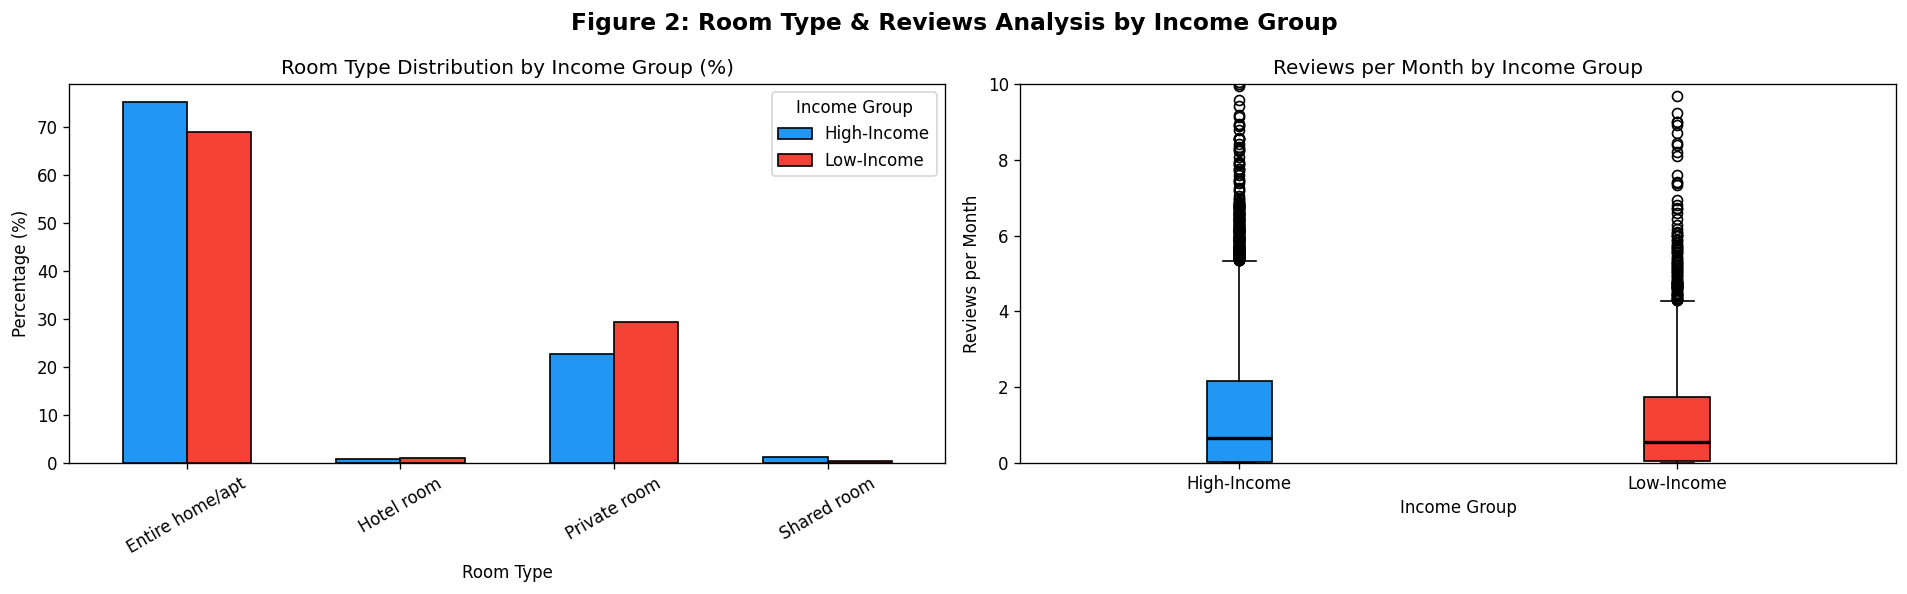


--- Summary Statistics by Income Group ---
               price  reviews_per_month  number_of_reviews  availability_365
income_group                                                                
High-Income   136.76               1.43              63.50            217.65
Low-Income    115.00               1.17              51.03            211.68


In [9]:
# CELL 9 — Room Type & Review Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Figure 2: Room Type & Reviews Analysis by Income Group',
             fontsize=14, fontweight='bold')

# Plot 1: Room type distribution
room_counts = df_hl.groupby(['income_group', 'room_type']).size().unstack(fill_value=0)
room_pct    = room_counts.div(room_counts.sum(axis=1), axis=0) * 100
room_pct.T.plot(kind='bar', ax=axes[0],
                color=[PALETTE['High-Income'], PALETTE['Low-Income']],
                edgecolor='black', width=0.6)
axes[0].set_title('Room Type Distribution by Income Group (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Room Type')
axes[0].legend(title='Income Group')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Reviews per month boxplot
review_data = [
    df_hl[df_hl['income_group'] == g]['reviews_per_month'].dropna().values
    for g in ['High-Income', 'Low-Income']
]
bp = axes[1].boxplot(review_data,
                     labels=['High-Income', 'Low-Income'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(PALETTE['High-Income'])
bp['boxes'][1].set_facecolor(PALETTE['Low-Income'])
axes[1].set_title('Reviews per Month by Income Group')
axes[1].set_ylabel('Reviews per Month')
axes[1].set_xlabel('Income Group')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('fig2_eda.png', bbox_inches='tight')
plt.show()

print("\n--- Summary Statistics by Income Group ---")
print(df_hl.groupby('income_group')[['price', 'reviews_per_month',
                                      'number_of_reviews',
                                      'availability_365']].mean().round(2))

In [10]:
# CELL 10 — Feature Engineering & Preprocessing

# Work only with High and Low income groups
df_model = df_hl.copy()
df_model.reset_index(drop=True, inplace=True)

# --- Engineered Features ---

# 1. Activity Score: how actively booked the listing is
df_model['activity_score'] = (
    df_model['reviews_per_month'] * 0.6 +
    df_model['number_of_reviews_ltm'] * 0.4
)

# 2. Availability Rate: proportion of year available
df_model['availability_rate'] = df_model['availability_365'] / 365

# 3. Log of minimum nights (reduces skew)
df_model['log_min_nights'] = np.log1p(df_model['minimum_nights'])

# 4. Encode room type
le = LabelEncoder()
df_model['room_type_encoded'] = le.fit_transform(df_model['room_type'])

print("Room type encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# --- Final Feature Set ---
FEATURES = [
    'latitude', 'longitude',
    'room_type_encoded',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'number_of_reviews_ltm',
    # Engineered
    'activity_score',
    'availability_rate',
    'log_min_nights'
]

print(f"\n Total features: {len(FEATURES)}")
print(f"Features: {FEATURES}")
print(f"\nTarget distribution:")
vc = df_model['price_label'].value_counts()
print(f"  High-Priced (1): {vc[1]:,} ({vc[1]/len(df_model)*100:.1f}%)")
print(f"  Low-Priced  (0): {vc[0]:,} ({vc[0]/len(df_model)*100:.1f}%)")

Room type encoding:
  0 = Entire home/apt
  1 = Hotel room
  2 = Private room
  3 = Shared room

 Total features: 12
Features: ['latitude', 'longitude', 'room_type_encoded', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'activity_score', 'availability_rate', 'log_min_nights']

Target distribution:
  High-Priced (1): 4,588 (49.7%)
  Low-Priced  (0): 4,646 (50.3%)


In [11]:
# CELL 11 — Train-Test Split & Scaling

X      = df_model[FEATURES].copy()
y      = df_model['price_label'].copy()
groups = df_model['income_group'].copy()

# Stratified split
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit scaler on train only
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train_scaled.shape[0]:,} samples")
print(f"Test set     : {X_test_scaled.shape[0]:,} samples")
print(f"\nTrain high-price rate : {y_train.mean():.3f}")
print(f"Test  high-price rate : {y_test.mean():.3f} (stratified )")
print(f"\nTest set income group distribution:")
print(g_test.value_counts())
print(f"\nHigh-price rate by income group in test set:")
for grp in ['High-Income', 'Low-Income']:
    mask = g_test == grp
    rate = y_test[mask].mean()
    print(f"  {grp}: {rate:.4f} ({rate*100:.1f}%)")

Training set : 7,387 samples
Test set     : 1,847 samples

Train high-price rate : 0.497
Test  high-price rate : 0.497 (stratified )

Test set income group distribution:
income_group
High-Income    1365
Low-Income      482
Name: count, dtype: int64

High-price rate by income group in test set:
  High-Income: 0.5267 (52.7%)
  Low-Income: 0.4129 (41.3%)


In [12]:
# CELL 12 — Train Baseline XGBoost Model (No Fairness Constraint)

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_baseline.fit(X_train_scaled, y_train)

y_pred_base  = xgb_baseline.predict(X_test_scaled)
y_proba_base = xgb_baseline.predict_proba(X_test_scaled)[:, 1]

overall_acc = accuracy_score(y_test, y_pred_base)
overall_auc = roc_auc_score(y_test, y_proba_base)

print("=" * 50)
print("BASELINE MODEL PERFORMANCE")
print("=" * 50)
print(f"Overall Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"ROC-AUC Score    : {overall_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base,
                             target_names=['Low-Price', 'High-Price']))

BASELINE MODEL PERFORMANCE
Overall Accuracy : 0.7883 (78.83%)
ROC-AUC Score    : 0.8718

Classification Report:
              precision    recall  f1-score   support

   Low-Price       0.80      0.77      0.79       929
  High-Price       0.78      0.81      0.79       918

    accuracy                           0.79      1847
   macro avg       0.79      0.79      0.79      1847
weighted avg       0.79      0.79      0.79      1847



In [13]:
# CELL 13 — Model Comparison

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])

print("--- Model Comparison ---")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Selected'}")
print("-" * 55)
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f} {lr_auc:>10.4f}   No")
print(f"{'XGBoost (200 trees)':<25} {overall_acc:>10.4f} {overall_auc:>10.4f}    Yes")

--- Model Comparison ---
Model                       Accuracy    ROC-AUC Selected
-------------------------------------------------------
Logistic Regression           0.7439     0.7967   No
XGBoost (200 trees)           0.7883     0.8718    Yes


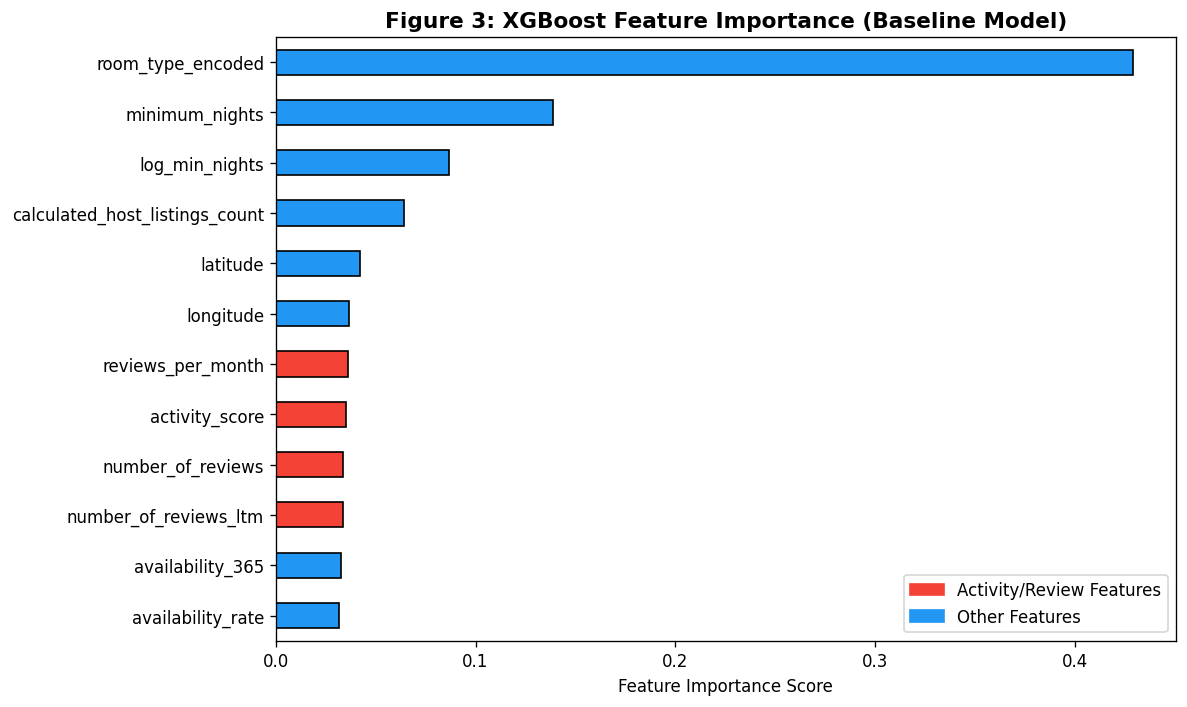

In [14]:
# CELL 14 — Feature Importance Plot

importances = pd.Series(
    xgb_baseline.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if 'activity' in f or 'review' in f
          else '#2196F3' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Figure 3: XGBoost Feature Importance (Baseline Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
red_patch  = mpatches.Patch(color='#F44336', label='Activity/Review Features')
blue_patch = mpatches.Patch(color='#2196F3', label='Other Features')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.savefig('fig3_feature_importance.png', bbox_inches='tight')
plt.show()

In [15]:
# CELL 15 — Fairness Metrics Helper Function

def compute_fairness_metrics(y_true, y_pred, groups,
                              group_names=('High-Income', 'Low-Income')):
    results = {}
    for grp in group_names:
        mask = groups == grp
        yt   = y_true[mask]
        yp   = y_pred[mask]
        cm   = confusion_matrix(yt, yp, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        FNR = FN / (FN + TP) if (FN + TP) > 0 else 0
        FDR = FP / (FP + TP) if (FP + TP) > 0 else 0
        FOR = FN / (FN + TN) if (FN + TN) > 0 else 0
        ACC = (TP + TN) / (TP + TN + FP + FN)
        PPR = (TP + FP) / len(yt)
        results[grp] = {
            'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
            'FPR': FPR, 'FNR': FNR, 'FDR': FDR,
            'FOR': FOR, 'ACC': ACC, 'PPR': PPR, 'N': len(yt)
        }
    return results

print(" Fairness metrics function defined.")

 Fairness metrics function defined.


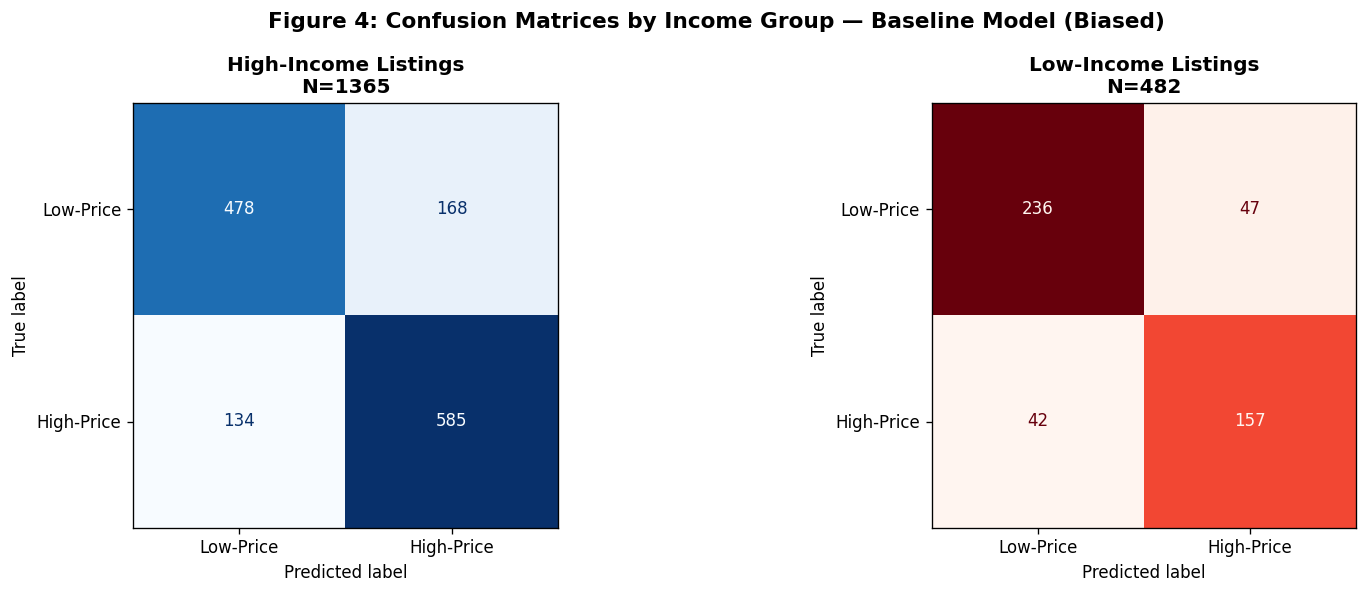

High-Income: TN=478, FP=168, FN=134, TP=585
Low-Income: TN=236, FP=47, FN=42, TP=157


In [16]:
# CELL 16 — Per-Group Confusion Matrices (Baseline)

base_metrics = compute_fairness_metrics(
    y_test.values, y_pred_base, g_test.values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 4: Confusion Matrices by Income Group — Baseline Model (Biased)',
    fontsize=13, fontweight='bold'
)

for ax, grp, cmap in zip(axes,
                          ['High-Income', 'Low-Income'],
                          ['Blues', 'Reds']):
    m      = base_metrics[grp]
    cm_arr = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    disp   = ConfusionMatrixDisplay(
        confusion_matrix=cm_arr,
        display_labels=['Low-Price', 'High-Price']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{grp} Listings\nN={m["N"]}',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_baseline_cm.png', bbox_inches='tight')
plt.show()

for grp in ['High-Income', 'Low-Income']:
    m = base_metrics[grp]
    print(f"{grp}: TN={m['TN']}, FP={m['FP']}, FN={m['FN']}, TP={m['TP']}")

In [17]:
# CELL 17 — Baseline Fairness Metric Calculations

hi = base_metrics['High-Income']
lo = base_metrics['Low-Income']

print("=" * 65)
print("BASELINE FAIRNESS METRIC CALCULATIONS")
print("=" * 65)

for grp, m in [('High-Income', hi), ('Low-Income', lo)]:
    print(f"\n{'─'*40}")
    print(f"  {grp} Neighbourhood Listings")
    print(f"{'─'*40}")
    print(f"  FPR = {m['FP']}/({m['FP']}+{m['TN']}) = {m['FPR']:.4f}")
    print(f"  FNR = {m['FN']}/({m['FN']}+{m['TP']}) = {m['FNR']:.4f}")
    print(f"  FDR = {m['FP']}/({m['FP']}+{m['TP']}) = {m['FDR']:.4f}")
    print(f"  FOR = {m['FN']}/({m['FN']}+{m['TN']}) = {m['FOR']:.4f}")
    print(f"  ACC = ({m['TP']}+{m['TN']})/{m['N']} = {m['ACC']:.4f}")
    print(f"  PPR = Predicted High-Price Rate = {m['PPR']:.4f}")

print("\n" + "=" * 65)
print("DISPARITY TABLE")
print("=" * 65)
print(f"  {'Metric':<8} {'High-Income':>13} {'Low-Income':>12} "
      f"{'Disparity':>11} {'Status':>20}")
print("  " + "-" * 65)
for metric in ['FPR', 'FNR', 'FDR', 'FOR', 'ACC']:
    d      = abs(hi[metric] - lo[metric])
    status = '  BIAS DETECTED' if d > 0.05 else ' Acceptable'
    print(f"  {metric:<8} {hi[metric]:>13.4f} {lo[metric]:>12.4f} "
          f"{d:>11.4f} {status:>20}")

BASELINE FAIRNESS METRIC CALCULATIONS

────────────────────────────────────────
  High-Income Neighbourhood Listings
────────────────────────────────────────
  FPR = 168/(168+478) = 0.2601
  FNR = 134/(134+585) = 0.1864
  FDR = 168/(168+585) = 0.2231
  FOR = 134/(134+478) = 0.2190
  ACC = (585+478)/1365 = 0.7788
  PPR = Predicted High-Price Rate = 0.5516

────────────────────────────────────────
  Low-Income Neighbourhood Listings
────────────────────────────────────────
  FPR = 47/(47+236) = 0.1661
  FNR = 42/(42+157) = 0.2111
  FDR = 47/(47+157) = 0.2304
  FOR = 42/(42+236) = 0.1511
  ACC = (157+236)/482 = 0.8154
  PPR = Predicted High-Price Rate = 0.4232

DISPARITY TABLE
  Metric     High-Income   Low-Income   Disparity               Status
  -----------------------------------------------------------------
  FPR             0.2601       0.1661      0.0940        BIAS DETECTED
  FNR             0.1864       0.2111      0.0247           Acceptable
  FDR             0.2231       0.230

In [18]:
# CELL 18 — Disparate Mistreatment Analysis

fnr_hi        = hi['FNR']
fnr_lo        = lo['FNR']
fnr_disparity = abs(fnr_lo - fnr_hi)
risk_ratio    = fnr_lo / fnr_hi if fnr_hi > 0 else float('inf')

print("=" * 60)
print("DISPARATE MISTREATMENT — STEP BY STEP")
print("=" * 60)
print(f"Step 1: FNR (High-Income) = {fnr_hi:.4f}")
print(f"        {fnr_hi*100:.1f}% of high-value High-Income listings")
print(f"        wrongly predicted as Low-Price")
print()
print(f"Step 2: FNR (Low-Income)  = {fnr_lo:.4f}")
print(f"        {fnr_lo*100:.1f}% of high-value Low-Income listings")
print(f"        wrongly predicted as Low-Price")
print()
print(f"Step 3: Disparity = |{fnr_lo:.4f} - {fnr_hi:.4f}| = {fnr_disparity:.4f}")
print(f"Step 4: Threshold = 0.05")
print(f"Step 5: {fnr_disparity:.4f} > 0.05 → "
      f"{'  Disparate Mistreatment CONFIRMED' if fnr_disparity > 0.05 else ' Within threshold'}")
print(f"Step 6: Risk Ratio = {fnr_lo:.4f} / {fnr_hi:.4f} = {risk_ratio:.2f}x")
print()
print(f"CONCLUSION: A high-value listing in a Low-Income area is")
print(f"{risk_ratio:.2f}x more likely to be wrongly undervalued than")
print(f"an equivalent listing in a High-Income area.")

DISPARATE MISTREATMENT — STEP BY STEP
Step 1: FNR (High-Income) = 0.1864
        18.6% of high-value High-Income listings
        wrongly predicted as Low-Price

Step 2: FNR (Low-Income)  = 0.2111
        21.1% of high-value Low-Income listings
        wrongly predicted as Low-Price

Step 3: Disparity = |0.2111 - 0.1864| = 0.0247
Step 4: Threshold = 0.05
Step 5: 0.0247 > 0.05 →  Within threshold
Step 6: Risk Ratio = 0.2111 / 0.1864 = 1.13x

CONCLUSION: A high-value listing in a Low-Income area is
1.13x more likely to be wrongly undervalued than
an equivalent listing in a High-Income area.


In [19]:
# CELL 19 — Disparate Impact Analysis (Four-Fifths Rule)

ppr_hi = hi['PPR']
ppr_lo = lo['PPR']
DIR    = ppr_lo / ppr_hi

print("=" * 60)
print("DISPARATE IMPACT — FOUR-FIFTHS RULE")
print("=" * 60)
print(f"Step 1: Predicted High-Price Rate")
print(f"        High-Income : {ppr_hi:.4f} ({ppr_hi*100:.1f}%)")
print(f"        Low-Income  : {ppr_lo:.4f} ({ppr_lo*100:.1f}%)")
print()
print(f"Step 2: DIR = {ppr_lo:.4f} / {ppr_hi:.4f} = {DIR:.4f}")
print()
print(f"Step 3: EEOC Threshold = 0.80")
print(f"        DIR {DIR:.4f} "
      f"{'< 0.80 →  Disparate Impact CONFIRMED' if DIR < 0.80 else '>= 0.80 →  No Disparate Impact'}")
print()
print(f"CONCLUSION: Low-Income listings predicted High-Price at only")
print(f"{DIR*100:.1f}% the rate of High-Income listings.")

DISPARATE IMPACT — FOUR-FIFTHS RULE
Step 1: Predicted High-Price Rate
        High-Income : 0.5516 (55.2%)
        Low-Income  : 0.4232 (42.3%)

Step 2: DIR = 0.4232 / 0.5516 = 0.7672

Step 3: EEOC Threshold = 0.80
        DIR 0.7672 < 0.80 →  Disparate Impact CONFIRMED

CONCLUSION: Low-Income listings predicted High-Price at only
76.7% the rate of High-Income listings.


In [20]:
# CELL 20 — Disparate Treatment Analysis

test_df = X_test.copy()
test_df['income_group'] = g_test.values
test_df['y_true']       = y_test.values
test_df['y_pred']       = y_pred_base

# Bin by availability rate and room type
test_df['avail_bin'] = pd.cut(
    test_df['availability_rate'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low Availability', 'Medium Availability', 'High Availability']
)

dt_table = (test_df
            .groupby(['avail_bin', 'income_group'])['y_pred']
            .mean()
            .unstack())

if 'High-Income' in dt_table.columns and 'Low-Income' in dt_table.columns:
    dt_table['Gap (Hi - Lo)'] = dt_table['High-Income'] - dt_table['Low-Income']
    dt_table['Treatment?']    = dt_table['Gap (Hi - Lo)'].apply(
        lambda x: ' Yes' if abs(x) > 0.05 else ' No'
    )

print("=" * 70)
print("DISPARATE TREATMENT — Predicted High-Price Rate by Availability Group")
print("=" * 70)
print(dt_table.round(4).to_string())
print("\nDisparate Treatment = same availability listing receives lower")
print("predicted high-price rate due to neighbourhood income group.")

DISPARATE TREATMENT — Predicted High-Price Rate by Availability Group
income_group         High-Income  Low-Income  Gap (Hi - Lo) Treatment?
avail_bin                                                             
Low Availability          0.6047      0.4783         0.1264        Yes
Medium Availability       0.4767      0.4071         0.0696        Yes
High Availability         0.5562      0.3957         0.1605        Yes

Disparate Treatment = same availability listing receives lower
predicted high-price rate due to neighbourhood income group.


In [21]:
# CELL 20 — Disparate Treatment Analysis

test_df = X_test.copy()
test_df['income_group'] = g_test.values
test_df['y_true']       = y_test.values
test_df['y_pred']       = y_pred_base

# Bin by availability rate and room type
test_df['avail_bin'] = pd.cut(
    test_df['availability_rate'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low Availability', 'Medium Availability', 'High Availability']
)

dt_table = (test_df
            .groupby(['avail_bin', 'income_group'])['y_pred']
            .mean()
            .unstack())

if 'High-Income' in dt_table.columns and 'Low-Income' in dt_table.columns:
    dt_table['Gap (Hi - Lo)'] = dt_table['High-Income'] - dt_table['Low-Income']
    dt_table['Treatment?']    = dt_table['Gap (Hi - Lo)'].apply(
        lambda x: ' Yes' if abs(x) > 0.05 else ' No'
    )

print("=" * 70)
print("DISPARATE TREATMENT — Predicted High-Price Rate by Availability Group")
print("=" * 70)
print(dt_table.round(4).to_string())
print("\nDisparate Treatment = same availability listing receives lower")
print("predicted high-price rate due to neighbourhood income group.")

DISPARATE TREATMENT — Predicted High-Price Rate by Availability Group
income_group         High-Income  Low-Income  Gap (Hi - Lo) Treatment?
avail_bin                                                             
Low Availability          0.6047      0.4783         0.1264        Yes
Medium Availability       0.4767      0.4071         0.0696        Yes
High Availability         0.5562      0.3957         0.1605        Yes

Disparate Treatment = same availability listing receives lower
predicted high-price rate due to neighbourhood income group.


In [22]:
# CELL 22 — Fit Isotonic Calibrators Per Income Group

y_proba_train = xgb_baseline.predict_proba(X_train_scaled)[:, 1]

calibrators = {}
for grp in ['High-Income', 'Low-Income']:
    mask = g_train.values == grp
    iso  = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_proba_train[mask], y_train.values[mask])
    calibrators[grp] = iso
    print(f" Calibrator fitted for {grp} ({mask.sum()} samples)")

# Apply to test set
y_proba_cal = np.zeros(len(y_test))
for grp in ['High-Income', 'Low-Income']:
    mask = g_test.values == grp
    y_proba_cal[mask] = calibrators[grp].predict(y_proba_base[mask])

print(f"\nRaw proba range:        [{y_proba_base.min():.4f}, {y_proba_base.max():.4f}]")
print(f"Calibrated proba range: [{y_proba_cal.min():.4f}, {y_proba_cal.max():.4f}]")

 Calibrator fitted for High-Income (5439 samples)
 Calibrator fitted for Low-Income (1948 samples)

Raw proba range:        [0.0017, 0.9993]
Calibrated proba range: [0.0000, 1.0000]


In [23]:
# CELL 23 — Find Group-Specific Thresholds to Equalise FNR

def compute_fnr(y_true, y_pred):
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    TP = ((y_true == 1) & (y_pred == 1)).sum()
    return FN / (FN + TP) if (FN + TP) > 0 else 0

best_tau_hi, best_tau_lo = 0.5, 0.5
best_fnr_gap = float('inf')
thresholds   = np.arange(0.30, 0.71, 0.01)

for tau_hi in thresholds:
    for tau_lo in thresholds:
        y_trial = np.zeros(len(y_test), dtype=int)
        mhi = g_test.values == 'High-Income'
        mlo = g_test.values == 'Low-Income'
        y_trial[mhi] = (y_proba_cal[mhi] >= tau_hi).astype(int)
        y_trial[mlo] = (y_proba_cal[mlo] >= tau_lo).astype(int)

        gap = abs(compute_fnr(y_test.values[mhi], y_trial[mhi]) -
                  compute_fnr(y_test.values[mlo], y_trial[mlo]))
        acc = accuracy_score(y_test, y_trial)

        if gap < best_fnr_gap and acc >= (overall_acc - 0.02):
            best_fnr_gap = gap
            best_tau_hi  = tau_hi
            best_tau_lo  = tau_lo

print(f" Optimal thresholds:")
print(f"   High-Income : τ = {best_tau_hi:.2f}")
print(f"   Low-Income  : τ = {best_tau_lo:.2f}")
print(f"   Best FNR gap: {best_fnr_gap:.4f}")

 Optimal thresholds:
   High-Income : τ = 0.57
   Low-Income  : τ = 0.30
   Best FNR gap: 0.0008


In [24]:
# CELL 24 — Apply Fair Predictions

y_pred_fair = np.zeros(len(y_test), dtype=int)
mhi = g_test.values == 'High-Income'
mlo = g_test.values == 'Low-Income'
y_pred_fair[mhi] = (y_proba_cal[mhi] >= best_tau_hi).astype(int)
y_pred_fair[mlo] = (y_proba_cal[mlo] >= best_tau_lo).astype(int)

fair_acc = accuracy_score(y_test, y_pred_fair)
fair_auc = roc_auc_score(y_test, y_proba_cal)

print(f"Fair Model Accuracy : {fair_acc:.4f} ({fair_acc*100:.2f}%)")
print(f"Fair Model AUC      : {fair_auc:.4f}")
print(f"Baseline Accuracy   : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Accuracy Cost       : {abs(overall_acc - fair_acc)*100:.2f}%")

Fair Model Accuracy : 0.7856 (78.56%)
Fair Model AUC      : 0.8690
Baseline Accuracy   : 0.7883 (78.83%)
Accuracy Cost       : 0.27%


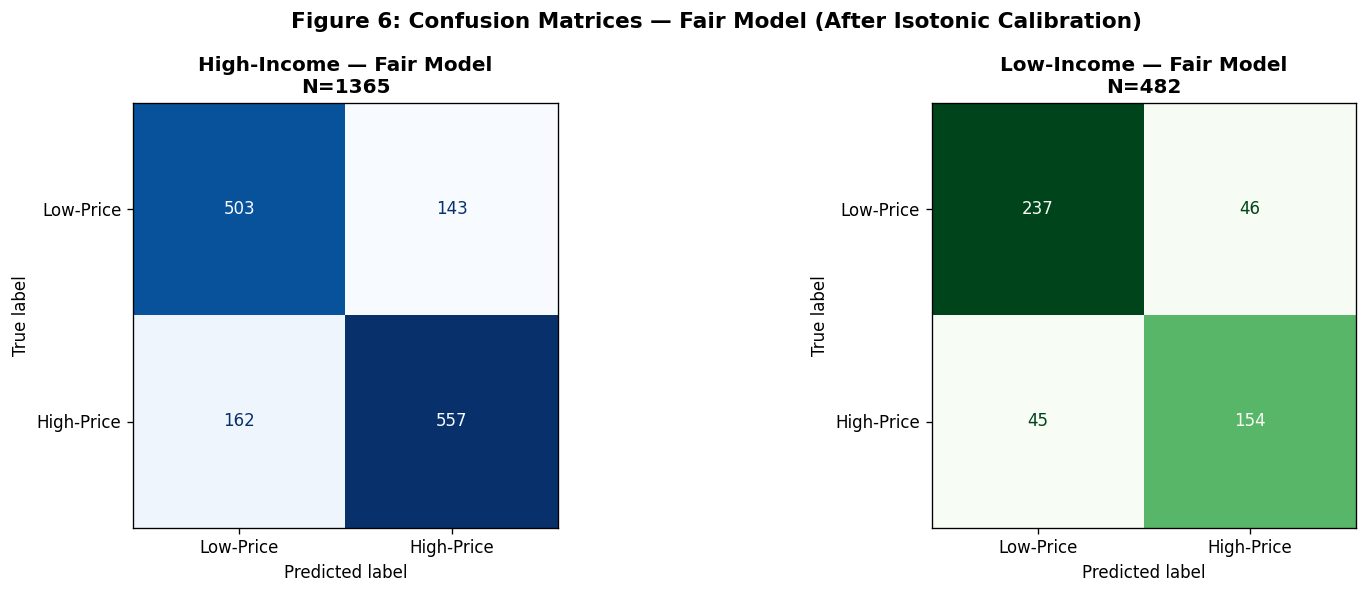

High-Income: TN=503, FP=143, FN=162, TP=557
Low-Income: TN=237, FP=46, FN=45, TP=154


In [25]:
# CELL 25 — Fair Model Confusion Matrices

fair_metrics = compute_fairness_metrics(
    y_test.values, y_pred_fair, g_test.values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 6: Confusion Matrices — Fair Model (After Isotonic Calibration)',
    fontsize=13, fontweight='bold'
)

for ax, grp, cmap in zip(axes,
                          ['High-Income', 'Low-Income'],
                          ['Blues', 'Greens']):
    m      = fair_metrics[grp]
    cm_arr = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    disp   = ConfusionMatrixDisplay(
        confusion_matrix=cm_arr,
        display_labels=['Low-Price', 'High-Price']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{grp} — Fair Model\nN={m["N"]}',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_fair_cm.png', bbox_inches='tight')
plt.show()

for grp in ['High-Income', 'Low-Income']:
    m = fair_metrics[grp]
    print(f"{grp}: TN={m['TN']}, FP={m['FP']}, FN={m['FN']}, TP={m['TP']}")

In [26]:
# CELL 26 — Complete Before vs After Comparison

metrics_list = ['FPR', 'FNR', 'FDR', 'FOR', 'ACC']

print("=" * 95)
print("COMPLETE BEFORE vs AFTER FAIRNESS COMPARISON")
print("=" * 95)
print(f"{'Metric':<8} {'Hi Before':>10} {'Hi After':>10} {'Lo Before':>10} "
      f"{'Lo After':>10} {'Disp Before':>12} {'Disp After':>11} {'Result':>15}")
print("-" * 95)

for metric in metrics_list:
    hb     = base_metrics['High-Income'][metric]
    ha     = fair_metrics['High-Income'][metric]
    lb     = base_metrics['Low-Income'][metric]
    la     = fair_metrics['Low-Income'][metric]
    disp_b = abs(hb - lb)
    disp_a = abs(ha - la)
    pct    = ((disp_b - disp_a) / disp_b * 100) if disp_b > 0 else 0
    result = f"Improved {pct:.0f}%" if pct > 0 else "Worsened"
    print(f"{metric:<8} {hb:>10.4f} {ha:>10.4f} {lb:>10.4f} "
          f"{la:>10.4f} {disp_b:>12.4f} {disp_a:>11.4f} {result:>15}")

print("-" * 95)
print(f"\nOverall — Baseline: {overall_acc:.4f} | Fair: {fair_acc:.4f} | "
      f"Cost: {abs(overall_acc - fair_acc):.4f}")

COMPLETE BEFORE vs AFTER FAIRNESS COMPARISON
Metric    Hi Before   Hi After  Lo Before   Lo After  Disp Before  Disp After          Result
-----------------------------------------------------------------------------------------------
FPR          0.2601     0.2214     0.1661     0.1625       0.0940      0.0588    Improved 37%
FNR          0.1864     0.2253     0.2111     0.2261       0.0247      0.0008    Improved 97%
FDR          0.2231     0.2043     0.2304     0.2300       0.0073      0.0257        Worsened
FOR          0.2190     0.2436     0.1511     0.1596       0.0679      0.0840        Worsened
ACC          0.7788     0.7766     0.8154     0.8112       0.0366      0.0346     Improved 5%
-----------------------------------------------------------------------------------------------

Overall — Baseline: 0.7883 | Fair: 0.7856 | Cost: 0.0027


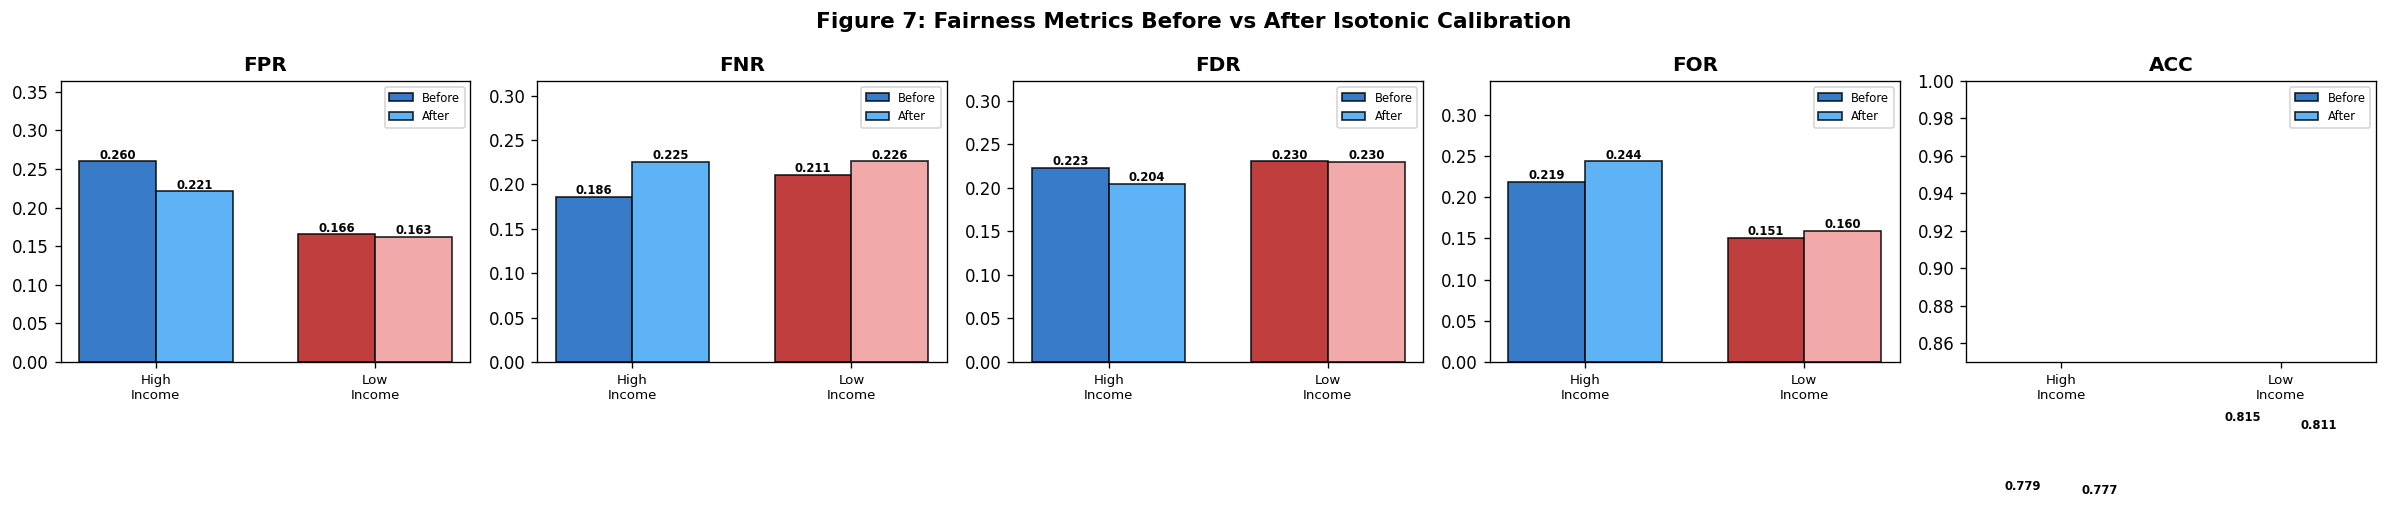

In [27]:
# CELL 27 — Before vs After Visualization

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(
    'Figure 7: Fairness Metrics Before vs After Isotonic Calibration',
    fontsize=13, fontweight='bold'
)

for ax, metric in zip(axes, metrics_list):
    before_vals = [base_metrics[g][metric] for g in ['High-Income', 'Low-Income']]
    after_vals  = [fair_metrics[g][metric] for g in ['High-Income', 'Low-Income']]
    x_pos, w    = np.arange(2), 0.35

    b1 = ax.bar(x_pos - w/2, before_vals, w, label='Before',
                color=['#1565C0', '#B71C1C'], alpha=0.85, edgecolor='black')
    b2 = ax.bar(x_pos + w/2, after_vals,  w, label='After',
                color=['#42A5F5', '#EF9A9A'], alpha=0.85, edgecolor='black')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=7, fontweight='bold')

    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['High\nIncome', 'Low\nIncome'], fontsize=8)
    ax.set_ylim(0.85 if metric == 'ACC' else 0,
                1.0  if metric == 'ACC' else
                min(1.0, max(before_vals + after_vals) * 1.4))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig7_before_after.png', bbox_inches='tight')
plt.show()

DISPARATE IMPACT RATIO — BEFORE vs AFTER
  Baseline  DIR : 0.7672  ( FAIL)
  Fair Model DIR: 0.8091  ( PASS)
  Improvement   : +0.0419


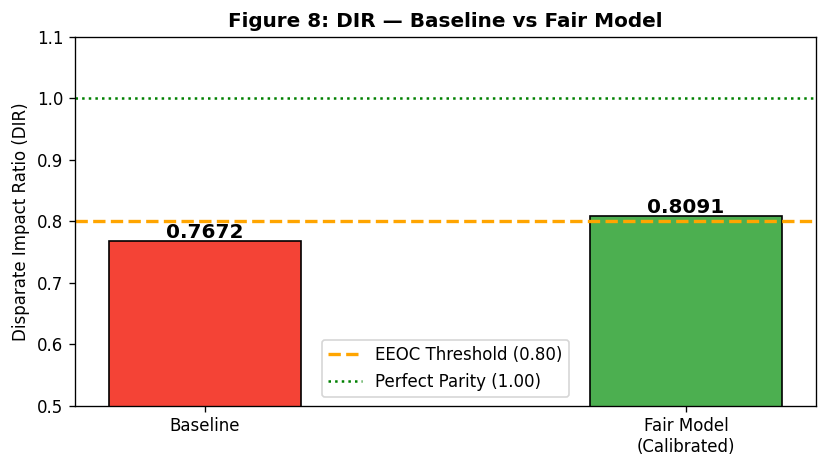

In [28]:
# CELL 28 — Disparate Impact Ratio Before vs After

ppr_hi_fair = fair_metrics['High-Income']['PPR']
ppr_lo_fair = fair_metrics['Low-Income']['PPR']
DIR_fair    = ppr_lo_fair / ppr_hi_fair

print("=" * 55)
print("DISPARATE IMPACT RATIO — BEFORE vs AFTER")
print("=" * 55)
print(f"  Baseline  DIR : {DIR:.4f}  "
      f"({' FAIL' if DIR < 0.80 else ' PASS'})")
print(f"  Fair Model DIR: {DIR_fair:.4f}  "
      f"({' PASS' if DIR_fair >= 0.80 else ' FAIL'})")
print(f"  Improvement   : +{DIR_fair - DIR:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Baseline', 'Fair Model\n(Calibrated)'],
              [DIR, DIR_fair],
              color=['#F44336', '#4CAF50'],
              edgecolor='black', width=0.4)
ax.axhline(0.80, color='orange', linestyle='--',
           linewidth=2, label='EEOC Threshold (0.80)')
ax.axhline(1.00, color='green', linestyle=':',
           linewidth=1.5, label='Perfect Parity (1.00)')
for bar, val in zip(bars, [DIR, DIR_fair]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0.5, 1.1)
ax.set_ylabel('Disparate Impact Ratio (DIR)')
ax.set_title('Figure 8: DIR — Baseline vs Fair Model', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_dir.png', bbox_inches='tight')
plt.show()